In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    classification_report, roc_curve, auc,
    precision_recall_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import joblib

In [5]:
# 2️⃣ Load & Preprocess Dataset
# =========================
df = pd.read_excel('Dataset.xlsx')
df.columns = [c.strip() for c in df.columns]

# Split Blood Pressure if present
if 'Blood pressure' in df.columns:
    df[['Systolic_BP', 'Diastolic_BP']] = df['Blood pressure'].str.split('/', expand=True)
    df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
    df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')
    df.drop(columns=['Blood pressure'], inplace=True)

In [6]:
# Select top important features
top_features = [
    'Discomfort Eye-strain',
    'Itchiness/Irritation in eye',
    'Redness in eye',
    'Average screen time',
    'Sleep duration',
    'Sleep quality',
    'Physical activity',
    'Systolic_BP',
    'Ongoing medication'
]

target = 'Dry Eye Disease'
df = df[top_features + [target]]

In [7]:
# Encoding + Cleaning
df[target] = df[target].map({"Yes": 1, "No": 0, "Y": 1, "N": 0}).fillna(df[target]).astype(int)

# Ensure all numeric & replace missing values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing or infinite values safely
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)


In [8]:
# 6️⃣ Split & Balance
X = df[top_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

In [9]:
# 7️⃣ Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Handle any NaN in scaled data (important for SVM)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)


c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [10]:
# FUNCTION FOR MODEL EVALUATION
# ===============================
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n📊 {model_name} CLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc:.4f}")

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.show()

    # --- PR Curve ---
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f'{model_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    }


📊 Random Forest (Calibrated) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.37      0.03      0.05      1393
           1       0.65      0.97      0.78      2607

    accuracy                           0.65      4000
   macro avg       0.51      0.50      0.42      4000
weighted avg       0.56      0.65      0.53      4000

ROC AUC Score: 0.4809


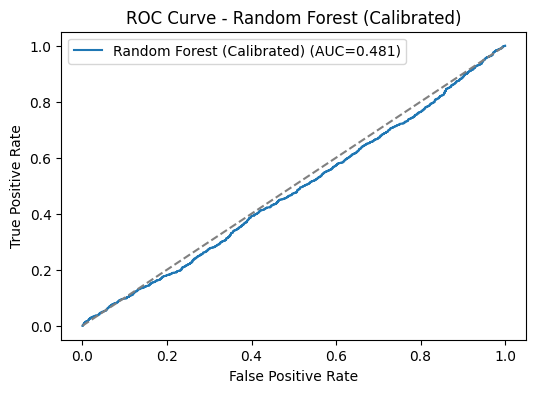

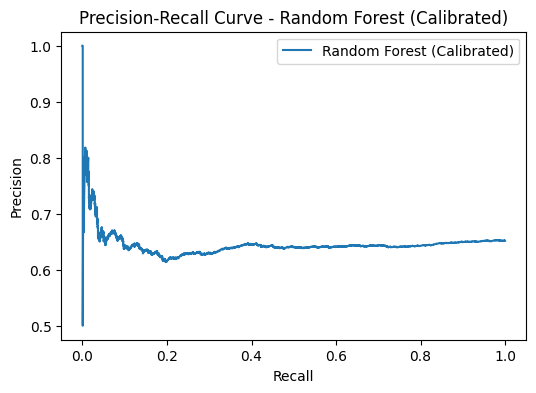

['dryeye_rf_model_calibrated.joblib']

In [11]:
# 8️⃣ RANDOM FOREST (Calibrated)
# ===============================
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_calibrated = CalibratedClassifierCV(rf, method='sigmoid', cv=5)
rf_metrics = evaluate_model(rf_calibrated, X_train_scaled, X_test_scaled, y_train_bal, y_test, "Random Forest (Calibrated)")
joblib.dump(rf_calibrated, 'dryeye_rf_model_calibrated.joblib')


📊 SVM (Calibrated) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.35      0.48      0.41      1393
           1       0.66      0.53      0.59      2607

    accuracy                           0.52      4000
   macro avg       0.51      0.51      0.50      4000
weighted avg       0.55      0.52      0.53      4000

ROC AUC Score: 0.5058


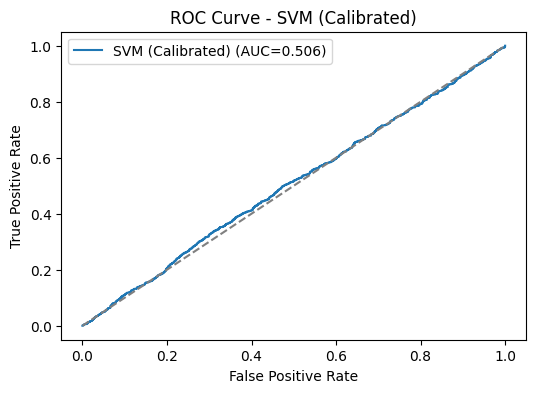

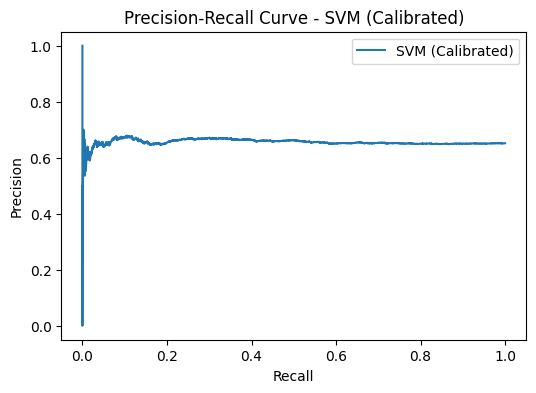

['dryeye_svm_model_calibrated.joblib']

In [12]:
# 9️⃣ SVM (Calibrated)
# ===============================
svm = SVC(kernel='rbf', probability=False, random_state=42)
svm_calibrated = CalibratedClassifierCV(svm, method='sigmoid', cv=5)
svm_metrics = evaluate_model(svm_calibrated, X_train_scaled, X_test_scaled, y_train_bal, y_test, "SVM (Calibrated)")
joblib.dump(svm_calibrated, 'dryeye_svm_model_calibrated.joblib')

[LightGBM] [Info] Number of positive: 8344, number of negative: 8344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 16688, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 8344, number of negative: 8344
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 16688, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 8344, number of negative: 8344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 16688, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 8344, number of negative: 8344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 16688, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 8344, number of negative: 8344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 394
[LightGBM] [Info] Number of data points in the train set: 16688, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

📊 LightGBM (Calibrated) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.32      0.27      0.30      1393
           1       0.64      0.70      0.67      2607

    accuracy                           0.55      4000
   macro avg       0.48      0.48      0.48      4000
weighted avg       0.53      0.55      0.54      4000

ROC AUC Score: 0.4849


c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\valida

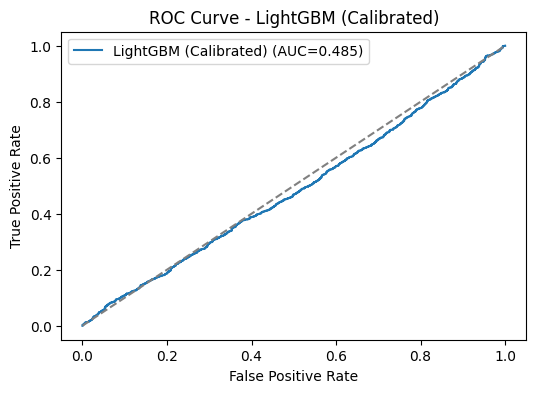

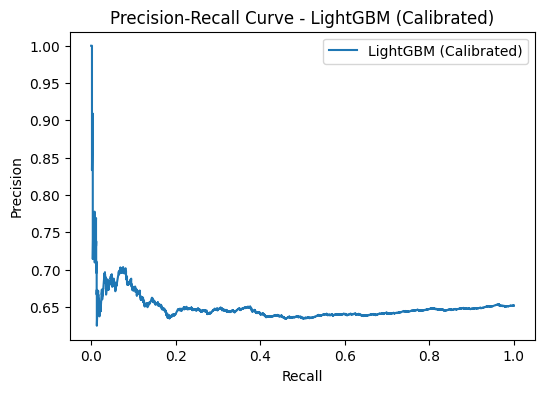

['dryeye_lgbm_model_calibrated.joblib']

In [13]:
# 🔟 LIGHTGBM (Calibrated)
# ===============================
lgbm = LGBMClassifier(n_estimators=300, random_state=42)
lgbm_calibrated = CalibratedClassifierCV(lgbm, method='sigmoid', cv=5)
lgbm_metrics = evaluate_model(lgbm_calibrated, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LightGBM (Calibrated)")
joblib.dump(lgbm_calibrated, 'dryeye_lgbm_model_calibrated.joblib')

c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:38:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:38:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:38:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HPVictus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:38:13] WARNI


📊 XGBoost (Calibrated) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.34      0.23      0.27      1393
           1       0.65      0.76      0.70      2607

    accuracy                           0.58      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.54      0.58      0.55      4000

ROC AUC Score: 0.4951


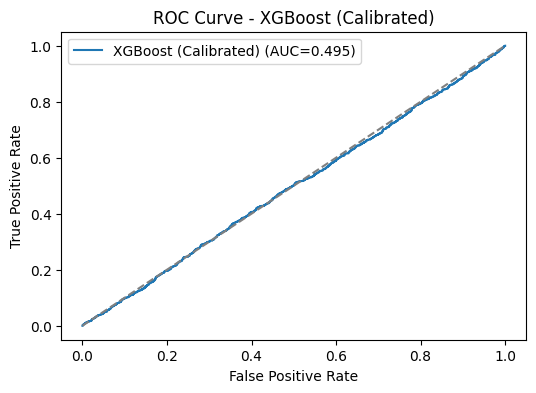

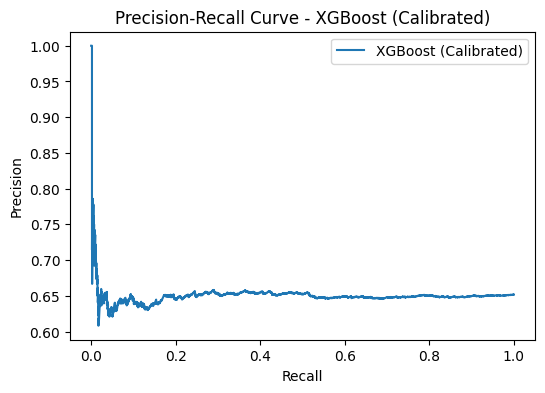

['dryeye_xgb_model_calibrated.joblib']

In [14]:
# 11️⃣ XGBOOST (Calibrated)
# ===============================
xgb = XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_calibrated = CalibratedClassifierCV(xgb, method='sigmoid', cv=5)
xgb_metrics = evaluate_model(xgb_calibrated, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGBoost (Calibrated)")
joblib.dump(xgb_calibrated, 'dryeye_xgb_model_calibrated.joblib')

In [15]:
# ===============================
# 12️⃣ SUMMARY TABLE
# ===============================
results_df = pd.DataFrame([rf_metrics, svm_metrics, lgbm_metrics, xgb_metrics])
print("\n============================")
print("📈 MODEL PERFORMANCE SUMMARY")
print("============================")
print(results_df.to_string(index=False))

# Save utilities
joblib.dump(scaler, 'dryeye_scaler.joblib')
joblib.dump(top_features, 'dryeye_features.joblib')

print("\n✅ All calibrated models trained, evaluated, and saved successfully!")


📈 MODEL PERFORMANCE SUMMARY
                     Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Random Forest (Calibrated)    0.6450     0.6525  0.9743    0.7815   0.4809
          SVM (Calibrated)    0.5150     0.6575  0.5339    0.5893   0.5058
     LightGBM (Calibrated)    0.5485     0.6418  0.6954    0.6675   0.4849
      XGBoost (Calibrated)    0.5757     0.6487  0.7614    0.7005   0.4951

✅ All calibrated models trained, evaluated, and saved successfully!


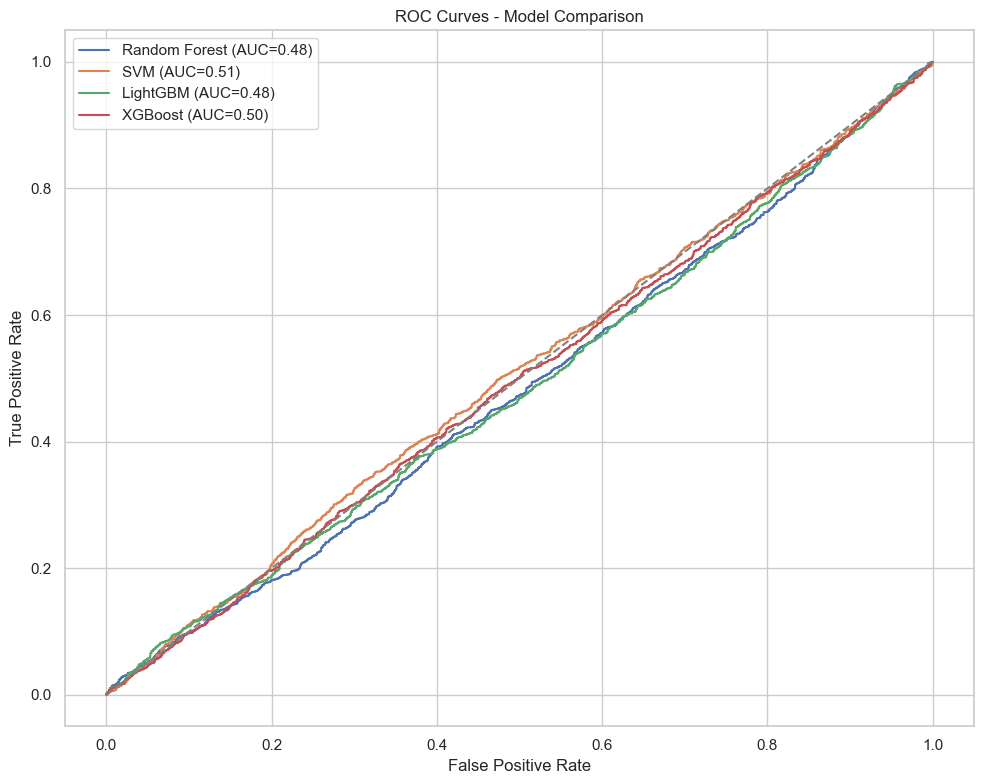

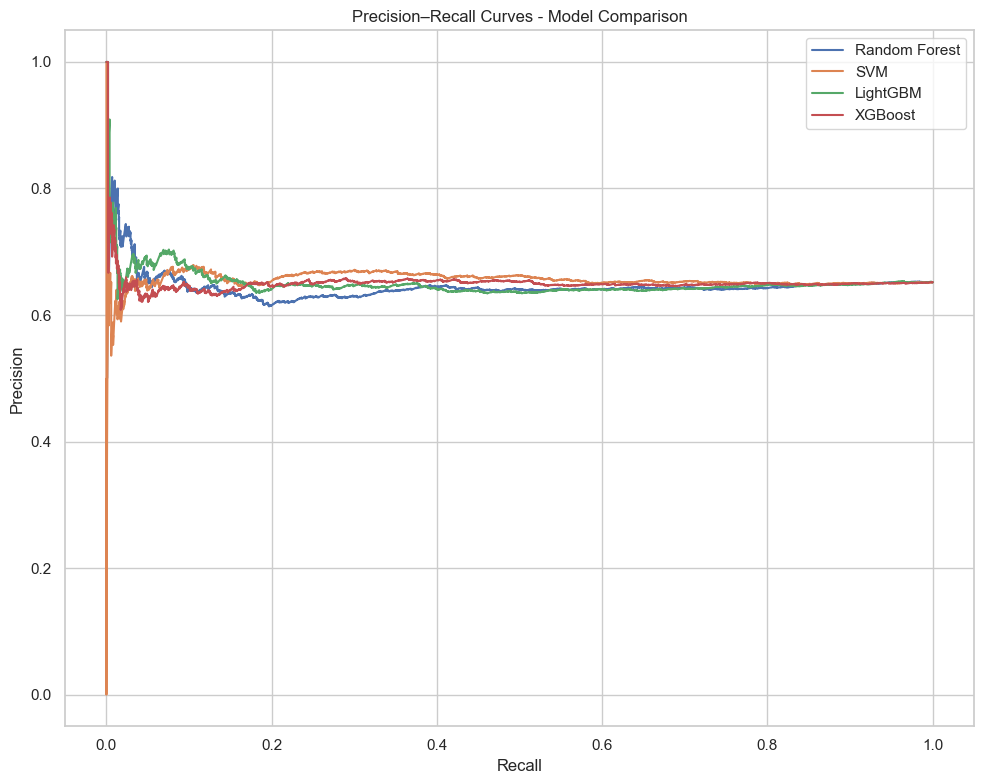

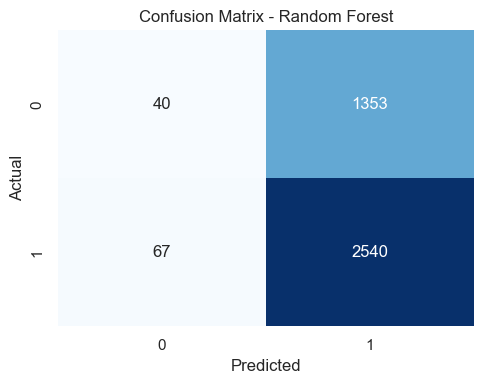

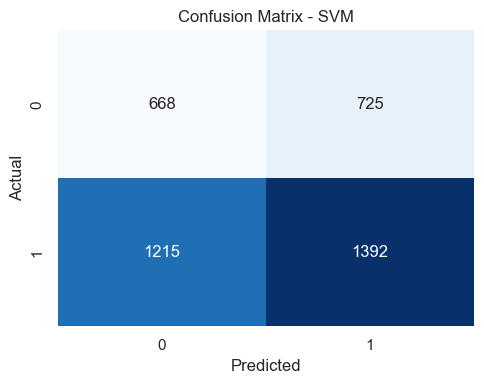

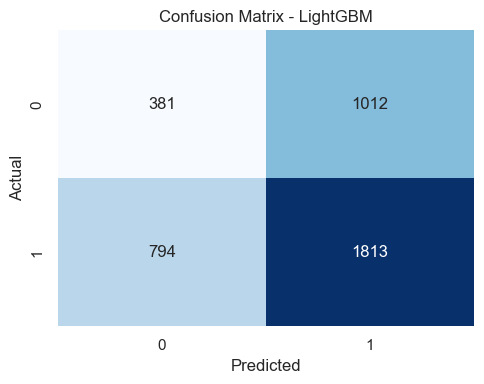

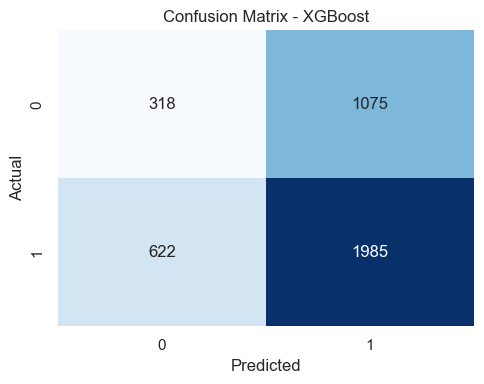


📊 Model Performance Comparison:

           Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1            SVM   0.51500   0.657534  0.533947  0.589331  0.505804
3        XGBoost   0.57575   0.648693  0.761412  0.700547  0.495133
2       LightGBM   0.54850   0.641770  0.695435  0.667526  0.484876
0  Random Forest   0.64500   0.652453  0.974300  0.781538  0.480882


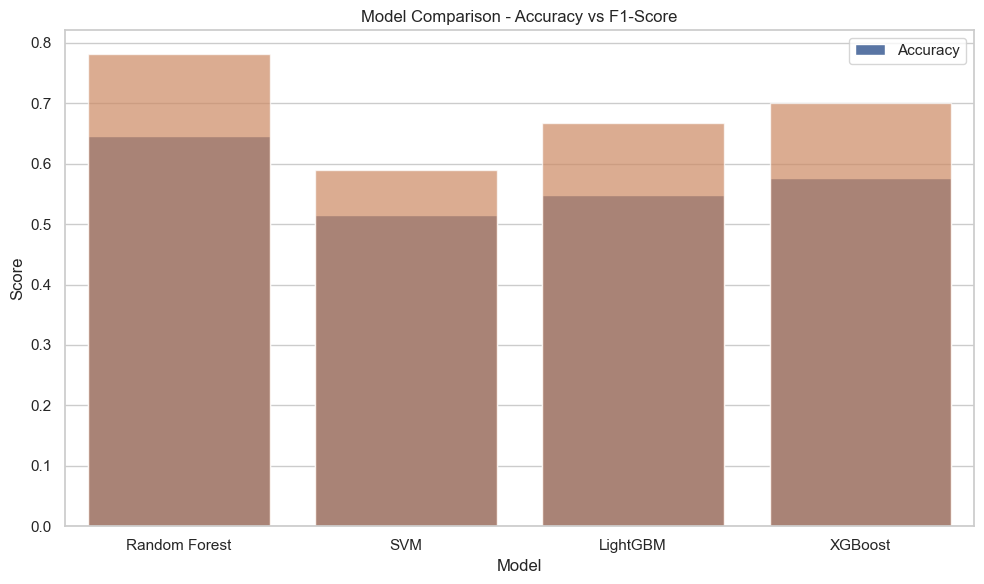

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
models = {
    "Random Forest": joblib.load("dryeye_rf_model_calibrated.joblib"),
    "SVM": joblib.load("dryeye_svm_model_calibrated.joblib"),
    "LightGBM": joblib.load("dryeye_lgbm_model_calibrated.joblib"),
    "XGBoost": joblib.load("dryeye_xgb_model_calibrated.joblib"),
}
# 3️⃣ Evaluate All Models
# -----------------------------
results = []

plt.figure(figsize=(10,8))

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    results.append([name, acc, prec, rec, f1, auc_score])
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ Precision-Recall Curves
# -----------------------------
plt.figure(figsize=(10,8))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Confusion Matrices
# -----------------------------
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6️⃣ Model Comparison Summary
# -----------------------------
comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])
print("\n📊 Model Performance Comparison:\n")
print(comparison_df.sort_values(by="ROC-AUC", ascending=False))

# Bar Chart Comparison
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=comparison_df, label="Accuracy")
sns.barplot(x="Model", y="F1-Score", data=comparison_df, alpha=0.7)
plt.title("Model Comparison - Accuracy vs F1-Score")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


📊 Random Forest (Calibrated) Results:
Accuracy:  0.6450
Precision: 0.6525
Recall:    0.9743
F1-Score:  0.7815
ROC-AUC:   0.4809


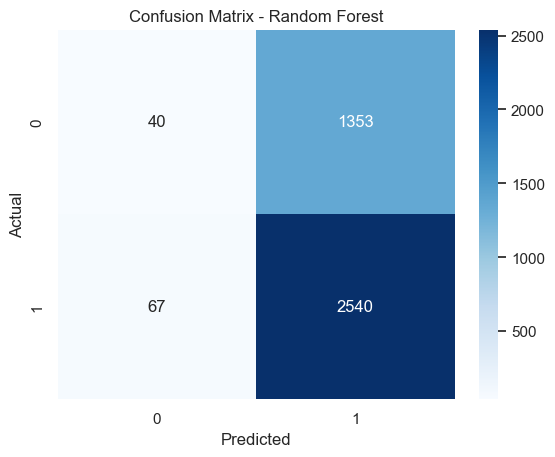

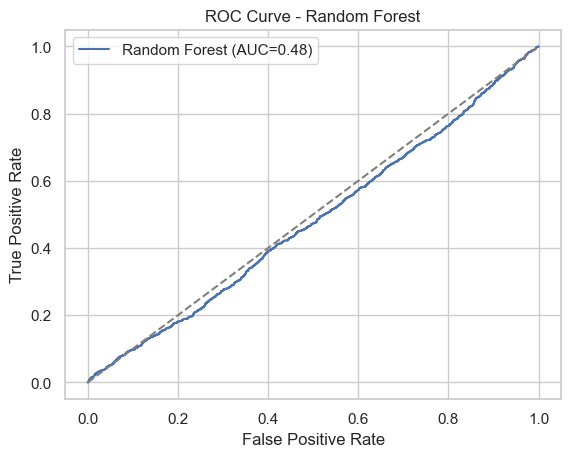

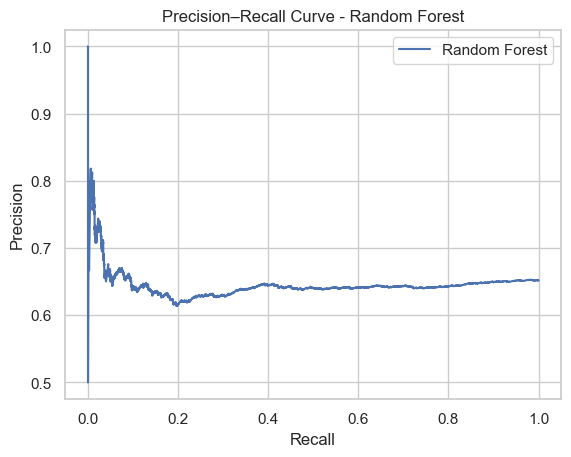

In [18]:
# Load Model
rf = joblib.load("dryeye_rf_model_calibrated.joblib")

# Predictions
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n📊 Random Forest (Calibrated) Results:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label='Random Forest')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")
plt.legend()
plt.show()



📊 SVM (Calibrated) Results:
Accuracy:  0.5150
Precision: 0.6575
Recall:    0.5339
F1-Score:  0.5893
ROC-AUC:   0.5058


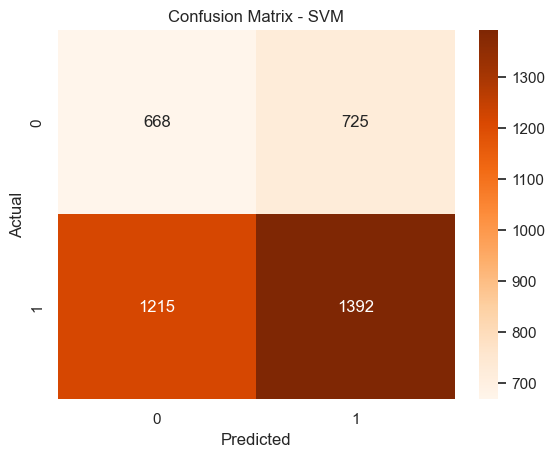

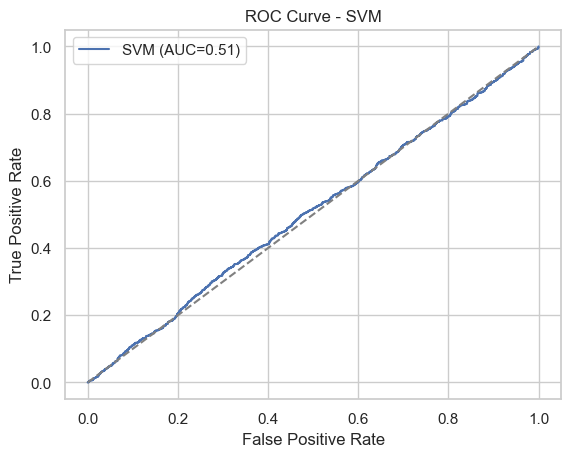

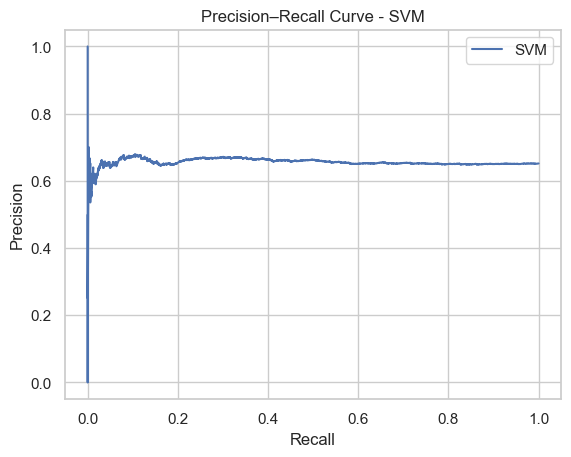

In [19]:
svm = joblib.load("dryeye_svm_model_calibrated.joblib")

y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n📊 SVM (Calibrated) Results:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'SVM (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label='SVM')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - SVM")
plt.legend()
plt.show()



📊 LightGBM (Calibrated) Results:
Accuracy:  0.5485
Precision: 0.6418
Recall:    0.6954
F1-Score:  0.6675
ROC-AUC:   0.4849


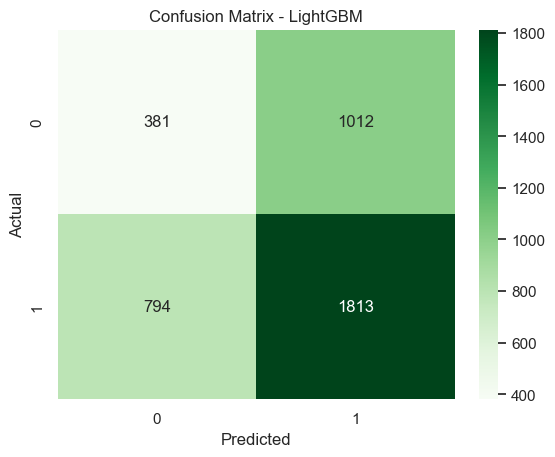

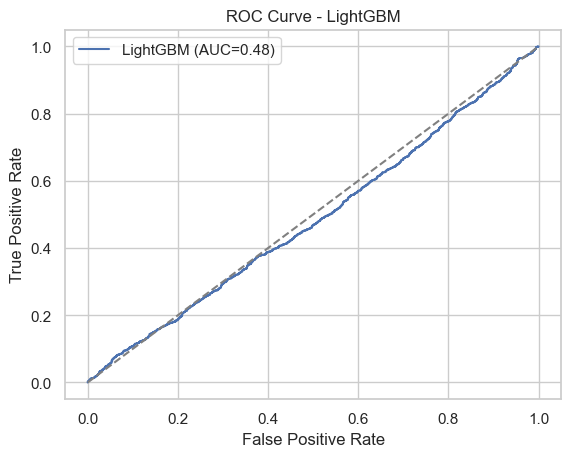

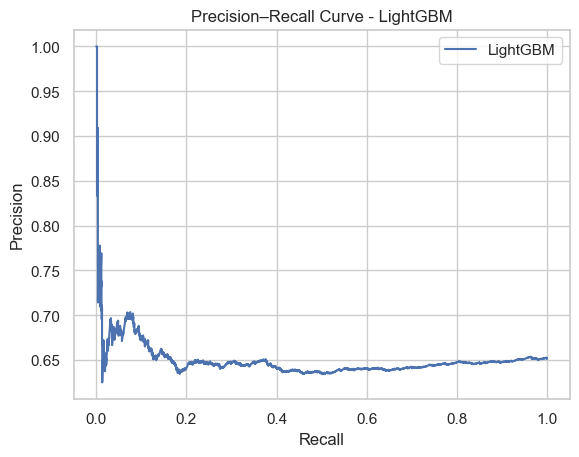

In [20]:
lgbm = joblib.load("dryeye_lgbm_model_calibrated.joblib")

y_pred = lgbm.predict(X_test_scaled)
y_proba = lgbm.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n📊 LightGBM (Calibrated) Results:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'LightGBM (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label='LightGBM')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - LightGBM")
plt.legend()
plt.show()



📊 XGBoost (Calibrated) Results:
Accuracy:  0.5757
Precision: 0.6487
Recall:    0.7614
F1-Score:  0.7005
ROC-AUC:   0.4951


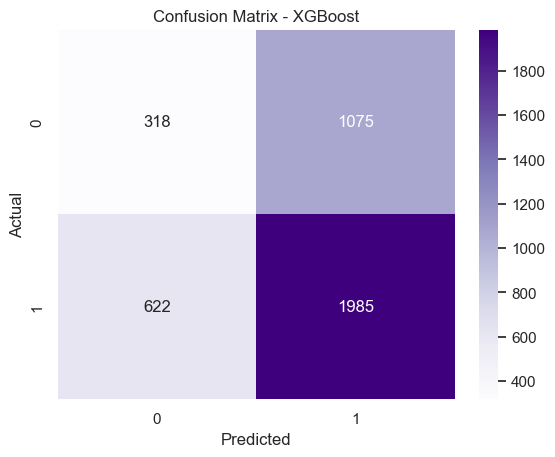

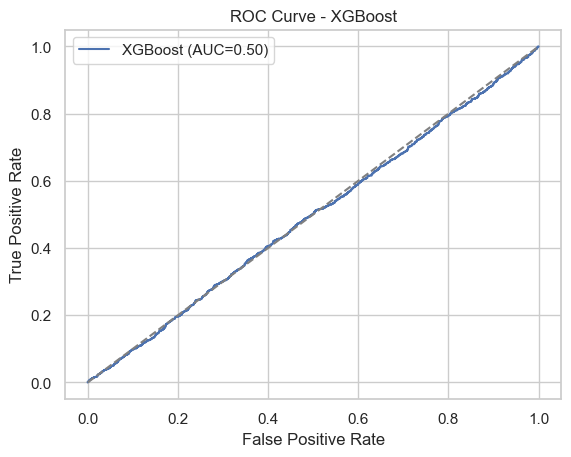

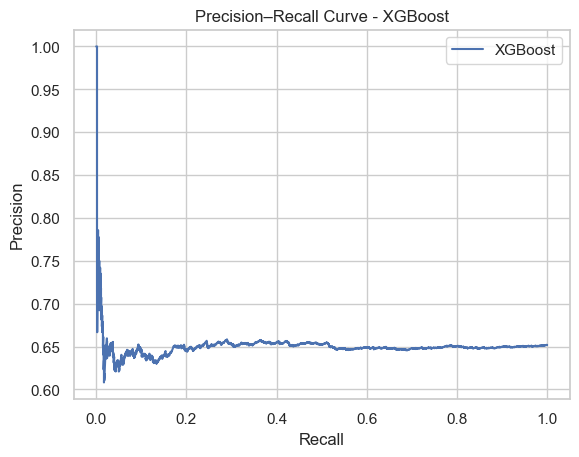

In [21]:
xgb = joblib.load("dryeye_xgb_model_calibrated.joblib")

y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n📊 XGBoost (Calibrated) Results:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label='XGBoost')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost")
plt.legend()
plt.show()



📊 Model Performance Summary:

           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Random Forest    0.6450     0.6525  0.9743    0.7815   0.4809
1            SVM    0.5150     0.6575  0.5339    0.5893   0.5058
2       LightGBM    0.5485     0.6418  0.6954    0.6675   0.4849
3        XGBoost    0.5758     0.6487  0.7614    0.7005   0.4951


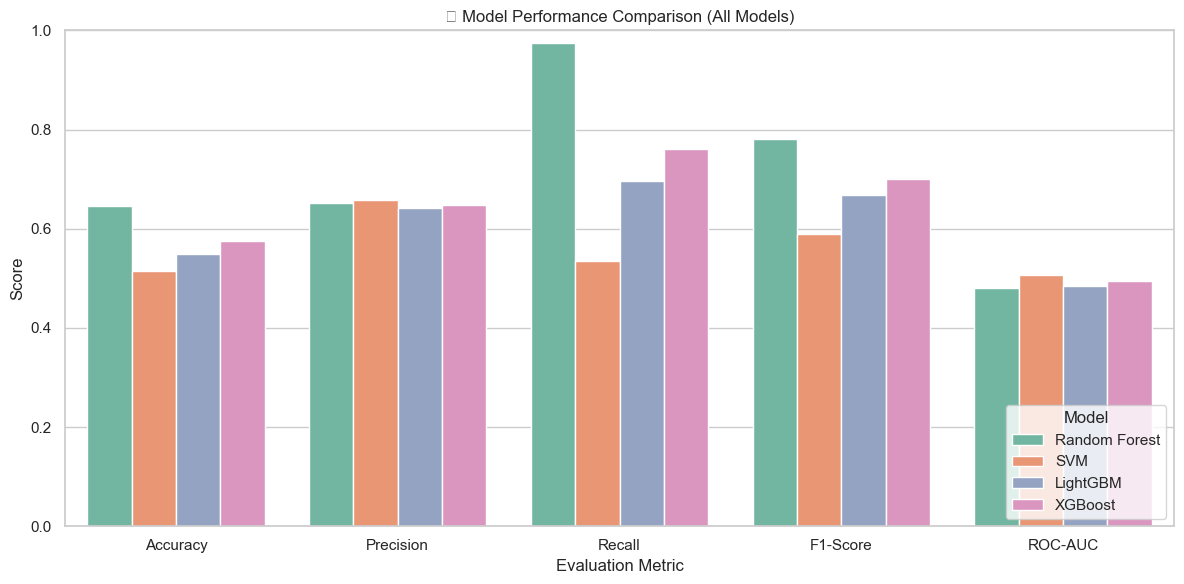


✅ Model performance comparison chart and CSV saved successfully!


<Figure size 640x480 with 0 Axes>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
models = {
    "Random Forest": joblib.load("dryeye_rf_model_calibrated.joblib"),
    "SVM": joblib.load("dryeye_svm_model_calibrated.joblib"),
    "LightGBM": joblib.load("dryeye_lgbm_model_calibrated.joblib"),
    "XGBoost": joblib.load("dryeye_xgb_model_calibrated.joblib"),
}

# -----------------------------
# 3️⃣ Evaluate All Models
# -----------------------------
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
print("\n📊 Model Performance Summary:\n")
print(results_df.round(4))

# -----------------------------
# 4️⃣ Visualization: Bar Charts
# -----------------------------
sns.set(style="whitegrid")
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plt.figure(figsize=(12, 6))
results_df_melted = results_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")

sns.barplot(data=results_df_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("📈 Model Performance Comparison (All Models)")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Save Visual (Optional)
# -----------------------------
results_df.to_csv("model_comparison_results.csv", index=False)
plt.savefig("model_comparison_bar_chart.png", dpi=300)
print("\n✅ Model performance comparison chart and CSV saved successfully!")

In [25]:
df_Data=pd.read_excel('Dataset.xlsx')
df_Data.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y
